# Proyecciones climáticas con datos grillados: climatología, anomalías y tendencia

**Geocomputación (1GEO20)** — PUCP, 2026-II — Semana 6


En este notebook procesamos datos grillados de proyecciones climáticas: cálculo de climatología, anomalías, promedio espacial y tendencia, para una región de estudio.

**Datos:** [NASA NEX-GDDP-CMIP6](https://developers.google.com/earth-engine/datasets/catalog/NASA_GDDP-CMIP6), variable `tasmax`, recortados a la región Lon(-85, -65) / Lat(-20, 5). 2 modelos (ACCESS-CM2, CMCC-ESM2), histórico (1950-2014) y 2 escenarios (SSP2-4.5, SSP5-8.5) hasta 2099, resolución mensual.

## 0. Descargar los datos 


In [2]:
# Alternativa para descargar la carpeta compartida de Google Drive
# Descomenta y reemplaza el ID por el de la carpeta compartida

#!pip install gdown -q

In [ ]:
#import gdown
#gdown.download_folder(id="1ZP-yqBKVZ8bYkbnxJL_hQpxl0qz9MP-6", output="datos_proyecciones", quiet=True)

# # o en Collab
# Descomenta y reemplaza el ID por el de la carpeta compartida
# !gdown --folder "ID_DE_LA_CARPETA_COMPARTIDA" -O datos_proyecciones

## 1. Setup y práctica con Xarray

In [38]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import kendalltau, theilslopes

In [39]:
# Ejemplo con un solo modelo y un solo escenario

# Define direcciones como variables
carpeta_datos = "datos_proyecciones/"
modelo = "ACCESS-CM2"
escenario = "ssp585"

# 1. Cargar el histórico
ruta_historico = carpeta_datos + modelo + "/" + f"tasmax_{modelo}_1950-2014_historical.nc"
historico = xr.open_dataset(ruta_historico)

# 2. Cargar los dos tramos del escenario
carpeta_modelo = carpeta_datos + modelo + "/"
tramo1 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2015-2049_{escenario}.nc")#["tasmax"]
tramo2 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2050-2099_{escenario}.nc")#["tasmax"]

In [40]:
# 3. Concatenar todo en una sola variable continua 1950-2099. 'dim="x"' define la variable referencia para
# la concatenación; esta variable se mantiene incambiable
completo_ejemplo = xr.concat([historico, tramo1, tramo2], dim="time")
print(completo_ejemplo.sizes, completo_ejemplo.time.min().values, "a", completo_ejemplo.time.max().values)

Frozen({'time': 1800, 'y': 100, 'x': 80}) 1950-01-01T00:00:00.000000000 a 2099-12-01T00:00:00.000000000


In [41]:
# 4. Climatología: agrupa los pasos de tiempo por mes del calendario
# (todos los eneros juntos, todos los febreros juntos, ...) y promedia cada grupo
# Como la columna "time" está en formato "datetime", se puede llamar al mes como "time.month"
climatologia_ejemplo = completo_ejemplo.groupby("time.month").mean("time")
print(climatologia_ejemplo.sizes)  # queda (month: 12, lat, lon): un campo promedio por cada mes del año

Frozen({'month': 12, 'y': 100, 'x': 80})


In [ ]:
climatologia_ejemplo

## 2. Cargar todos los datos y armar series continuas

Cada modelo tiene su propia subcarpeta, con el histórico y dos tramos por escenario:

```
datos_proyecciones/
├── ACCESS-CM2/
│   ├── tasmax_ACCESS-CM2_1950-2014_historical.nc
│   ├── tasmax_ACCESS-CM2_2015-2049_ssp245.nc
│   ├── tasmax_ACCESS-CM2_2050-2099_ssp245.nc
│   ├── tasmax_ACCESS-CM2_2015-2049_ssp585.nc
│   └── tasmax_ACCESS-CM2_2050-2099_ssp585.nc
└── CMCC-ESM2/
    └── ... (misma estructura)
```

El histórico es el mismo para ambos escenarios de un modelo, así que lo cargamos **una sola vez por modelo** y lo combinamos con cada escenario.

In [42]:
carpeta_datos = "datos_proyecciones/"

modelos = ["ACCESS-CM2", "CMCC-ESM2"]
escenarios = ["ssp245", "ssp585"]  # tal cual aparecen en los nombres de archivo

In [43]:
# Para ambos arrays, solo se está agarrando la data de la variable "tasmax"
def cargar_historico(modelo, carpeta):
    ruta = carpeta + modelo + f"/tasmax_{modelo}_1950-2014_historical.nc"
    return xr.open_dataset(ruta)["tasmax"] # Devuelve un dataArray

def cargar_escenario(modelo, escenario, carpeta):
    carpeta_modelo = carpeta + modelo + "/"
    tramo1 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2015-2049_{escenario}.nc")["tasmax"]
    tramo2 = xr.open_dataset(carpeta_modelo + f"tasmax_{modelo}_2050-2099_{escenario}.nc")["tasmax"]
    return xr.concat([tramo1, tramo2], dim="time")

In [44]:
# Se define una lista inicial
da_por_modelo = []
for modelo in modelos:
    # Se asignan los datos históricos a una variable
    historico = cargar_historico(modelo, carpeta_datos)
    # Se define una variable que se reinicia tras cada iteración
    da_por_escenario = []
    # Como cada modelo tiene dos escenarios, se llama otra iteración para cada escenario del modelo
    for escenario in escenarios:
        # Se asignan los datos de las proyecciones correspondientes al modelo y escenario de la iteración
        futuro = cargar_escenario(modelo, escenario, carpeta_datos)
        # Se asigna a la lista la concatenación de la data histórica con la del escenario
        da_por_escenario.append(xr.concat([historico, futuro], dim="time")) #.append devuelve una lista
    # Con la data de ambos escenarios para un modelo, se concatenan los datos con referencia a la 
    # dimensión "escenario". Si la dimensión no existe, el comando 'dim="escenario"' la crea. 
    serie_modelo = xr.concat(da_por_escenario, dim="escenario") # La lista se convierte en array
    # La serie está agrupada por escenario, pero no hay un valor asignado. La coordenada se asigna con los
    # valores de la variable 'escenarios'
    serie_modelo = serie_modelo.assign_coords(escenario=escenarios)
    # Se enlistan los datos en serie_modelo en la variable da_por_modelo
    da_por_modelo.append(serie_modelo)

# Se concatena la data por la dimensión 'modelo'. 
datos_completo = xr.concat(da_por_modelo, dim="modelo")
datos_completo = datos_completo.assign_coords(modelo=modelos)

In [ ]:
datos_completo

## 3. Climatología y anomalía

Calculamos la climatología mensual (promedio por mes dentro de un periodo base) y la anomalía respecto a esa climatología, a nivel de grilla completa (todavía sin promediar espacialmente).

El periodo base queda como parámetro modificable, más abajo lo van a cambiar ustedes en el Ejercicio 1.

In [45]:
periodo_base = (1985, 2014)  # años inicio y fin, ambos incluidos

def calcular_climatologia_anomalia(da, periodo_base):
    # Se asigna el valor de la tupla a variables diferentes
    inicio, fin = periodo_base
    # Se selecciona la data correspondiente al periodo de tiempo definido (histórico), tomando todos
    # los años completos
    base = da.sel(time=slice(f"{inicio}-01-01", f"{fin}-12-31"))
    # Se agrupan los datos por mes y se promedian los datos de mes de cada año, devolviendo una data
    # con 12 variables
    climatologia = base.groupby("time.month").mean("time")
    # La anomalía se calcula de toda la data (incluyendo proyecciones) agrupada por mes y restada con la
    # climatología promedio de cada mes correspondiente
    anomalia = da.groupby("time.month") - climatologia
    return climatologia, anomalia

climatologia, anomalia = calcular_climatologia_anomalia(datos_completo, periodo_base)

In [ ]:
anomalia

## 4. Inspección rápida (sin cartopy)

Revisar visualmente que el dominio esté bien y que la anomalía tenga sentido espacial, con  `.plot()` de xarray (sin mapa base, solo para inspección rápida).

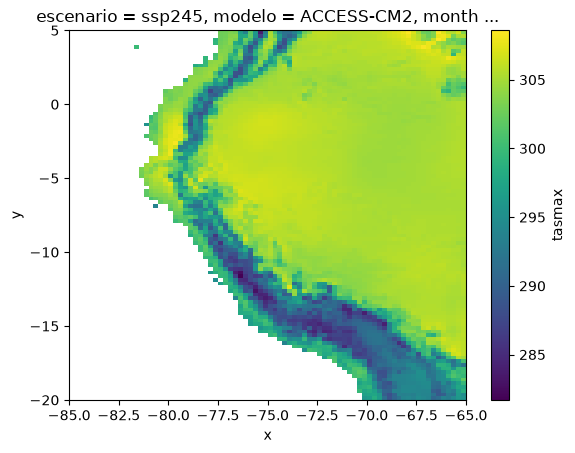

In [46]:
# Dominio: un mes cualquiera del histórico, para confirmar la extensión y forma de la grilla
#climatologia.sel(modelo="ACCESS-CM2",escenario="ssp245").isel(month=0).plot()

climatologia.sel(modelo="ACCESS-CM2",escenario="ssp245",month=12).plot()

#climatologia.sel(escenario="ssp245",month=12).plot(col='modelo')

#climatologia.sel(modelo="ACCESS-CM2",month=12).plot(col='escenario')
plt.show()

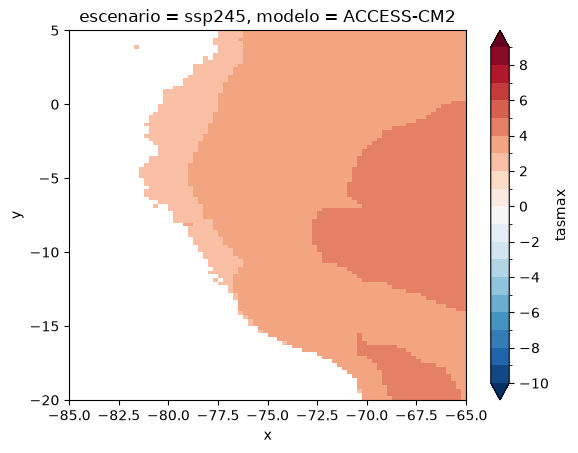

In [47]:
# Anomalía espacial: promedio de los últimos 10 años del siglo, SSP5-8.5
anomalia.sel(modelo="ACCESS-CM2",escenario="ssp245", time=slice("2090-01-01", "2099-12-31")).mean("time").plot(
    cmap="RdBu_r", center=0, levels=np.arange(-10,10), extend='both',
)
plt.show()

# Gráfico de anomalía para cada mes
#anomalia.sel(modelo="ACCESS-CM2",escenario="ssp245", time=slice("2090-01-01", "2099-12-31")).plot(
#    cmap="RdBu_r", center=0, levels=np.arange(-10,10), extend='both', col='time', col_wrap=3
#)
#plt.show()

### Ejercicio 1

Vuelve a calcular climatología y anomalía para ` "ACCESS-CM2" - "ssps585")`, esta vez con un periodo base distinto (por ejemplo, todo el histórico 1950-2014 en vez de 1985-2014).

Compara la anomalía de un mismo mes (por ejemplo junio de 2090) entre ambos periodos base. ¿Cuánto cambia? 

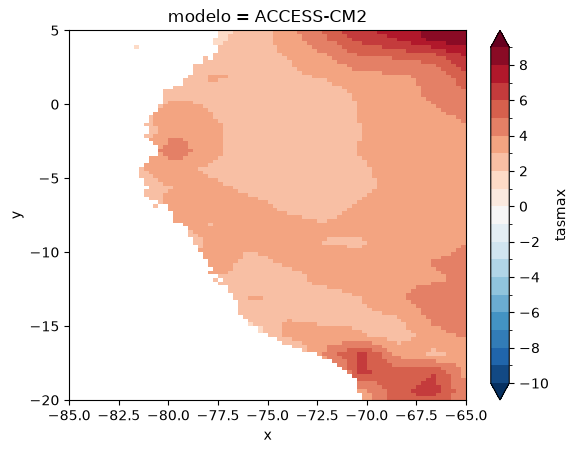

In [48]:
# Se define el periodo
nuevo_periodo = (1950, 2014)
climatologia2, anomalia2 = calcular_climatologia_anomalia(datos_completo, nuevo_periodo)

# Se selecciona el periodo de cada anomalía calculada
marzo_2050_anom = anomalia.sel(modelo='ACCESS-CM2',escenario='ssp245', time=slice("2050-03-01", "2050-03-31")).mean("time")
marzo_2050_anom2 = anomalia2.sel(modelo='ACCESS-CM2',escenario='ssp585', time=slice("2050-03-01", "2050-03-31")).mean("time")

diferencia = marzo_2050_anom2 - marzo_2050_anom

diferencia.plot(cmap="RdBu_r", center=0, levels=np.arange(-10,10), extend='both')

## 5. Promedio espacial (ponderado por latitud)

Para pasar de la grilla a una sola serie de tiempo por modelo y escenario, promediamos sobre el espacio ponderando la latitud ([.wighted()](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.weighted.html)). La región es opcional, si no se especifica se usa todo el dominio descargado, pero se puede acotar a una subregión dentro de él.

In [49]:
# Se define una función que recorta las coordenadas del dataArray y saca un promedio de los datos
def promedio_espacial(dataarray, lon_min=None, lon_max=None, lat_min=None, lat_max=None):
    # Recorte
    sub = dataarray
    if lon_min is not None or lon_max is not None:
        sub = sub.sel(x=slice(lon_min, lon_max))
    if lat_min is not None or lat_max is not None:
        sub = sub.sel(y=slice(lat_max, lat_min))

    # ponderamos por cos(lat): una celda cerca del ecuador cubre más área real
    # que una celda cerca de los 20°S, aunque ambas midan lo mismo en grados
    pesos = np.cos(np.deg2rad(sub["y"]))
    # sub.weighted(pesos): Vincula los pesos calculados a la dimensión espacial correspondiente (y)
    # .mean(dim=("y", "x")): Colapsa las dos dimensiones espaciales y calcula la media sobre el área
    return sub.weighted(pesos).mean(dim=("y", "x"))

In [50]:
# todo el dominio descargado

series_regionales = promedio_espacial(anomalia)

# Prueba para una subregión opcional (descomenta para probar)
# sub = promedio_espacial(anomalia.sel(modelo="ACCESS-CM2", escenario="ssps585"), lon_min=-80, lon_max=-70, lat_min=-15, lat_max=0)

In [ ]:
series_regionales.sel(modelo="ACCESS-CM2",escenario="ssp245")

## 6. De mensual a anual

In [51]:
series_anuales = series_regionales.groupby("time.year").mean("time")

In [ ]:
series_anuales

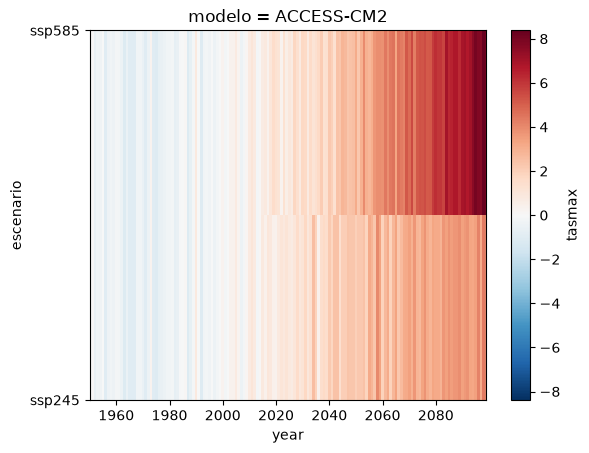

In [52]:
#series_anuales.sel(modelo="ACCESS-CM2",escenario="ssp245").plot()

series_anuales.sel(modelo="ACCESS-CM2").plot()

## 7. Test de tendencia (prueba)

 `kendalltau` para significancia, `theilslopes` para la magnitud.

In [53]:
def interpretar_tendencia(tau, p_valor, alpha=0.05):
    if p_valor < alpha and tau > 0:
        return "creciente"
    elif p_valor < alpha and tau < 0:
        return "decreciente"
    return "sin tendencia significativa"

serie_prueba = series_anuales.sel(modelo="ACCESS-CM2", escenario="ssp585")
anios = serie_prueba["year"].values
valores = serie_prueba.values

tau, p_valor = kendalltau(anios, valores)
pendiente, intercepto, ic_bajo, ic_alto = theilslopes(valores, anios, alpha=0.95)

print(f"ACCESS-CM2, ssp585: tau={tau:.3f}, p-valor={p_valor:.2e} -> {interpretar_tendencia(tau, p_valor)}")
print(f"Pendiente de Sen: {pendiente*10:.3f} °C/década (IC 95%: [{ic_bajo*10:.3f}, {ic_alto*10:.3f}])")

ACCESS-CM2, ssp585: tau=0.836, p-valor=4.88e-52 -> creciente
Pendiente de Sen: 0.571 °C/década (IC 95%: [0.523, 0.618])


### Ejercicio 2

Con el ejemplo de arriba como guía y el notebook `proyecciones_climaticas.ipynb`, aplica `kendalltau` y `theilslopes` a las **4 combinaciones** de `series_anuales` (2 modelos × 2 escenarios) en una interación, y junta los resultados en una tabla (`pd.DataFrame`).

¿Qué tanto difiere SSP2-4.5 de SSP5-8.5 dentro de un mismo modelo?

In [54]:
import pandas as pd

In [55]:
x = []

for modelo in modelos:
    for escenario in escenarios:
        s = series_anuales.sel(modelo=modelo, escenario=escenario)
        a = s["year"].values
        v = s.values
        tau, p_valor = kendalltau(a, v)
        pendiente, intercepto, ic_bajo, ic_alto = theilslopes(v, a, alpha=0.95)
        x.append({'MODELO': modelo,
             'ESCENARIO': escenario,
             'TAU': tau,
             'P_VALOR': p_valor,
             'PENDIENTE_C°_DECADA': pendiente*10})
        
df = pd.DataFrame(x)       


In [56]:
df

,MODELO,ESCENARIO,TAU,P_VALOR,PENDIENTE_C°_DECADA
0,ACCESS-CM2,ssp245,0.788814,1.545329e-46,0.355927
1,ACCESS-CM2,ssp585,0.835884,4.877285e-52,0.570887
2,CMCC-ESM2,ssp245,0.742640,1.898678e-41,0.281730
3,CMCC-ESM2,ssp585,0.789709,1.222890e-46,0.433025


#### Ensemble mean

In [57]:
ensemble_mean = series_anuales.mean("modelo")   # o anomalia.mean("modelo") para el dataarray de anomalías (time,x,y)

## 8. Gráfico final

Con lo que ya procesaron: anomalía anual de `tasmax`, por modelo y escenario.

In [58]:
h = series_anuales.sel(modelo='ACCESS-CM2', escenario='ssp245')
h["year"].shape

(150,)

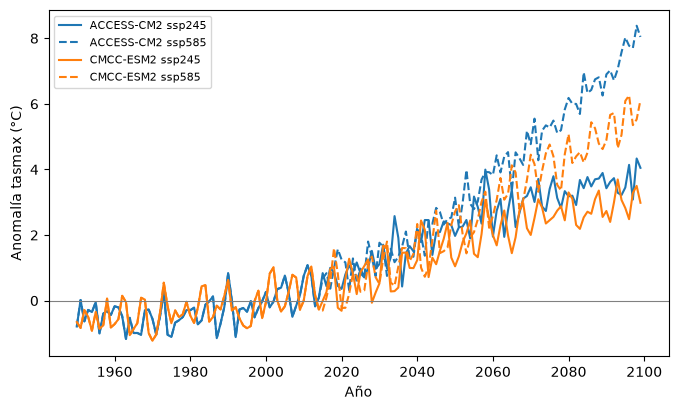

In [59]:
fig, ax = plt.subplots(figsize=(8, 4.5))

estilo_color = {"ACCESS-CM2": "tab:blue", "CMCC-ESM2": "tab:orange"}
estilo_linea = {"ssp245": "-", "ssp585": "--"}

for modelo in series_anuales.modelo.values:
    for escenario in series_anuales.escenario.values:
        serie = series_anuales.sel(modelo=modelo, escenario=escenario)
        ax.plot(serie["year"], serie.values,
            color=estilo_color[modelo], linestyle=estilo_linea[escenario],
            label=f"{modelo} {escenario}")

ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Año")
ax.set_ylabel("Anomalía tasmax (°C)")
ax.legend(fontsize=8)
plt.show()

### Ejercicio 3

Grafica la media del ensamble (los 2 modelos) para cada escenario, junto con el rango entre ambos modelos (mínimo-máximo, no una desviación estándar, con solo 2 modelos no tiene sentido estadístico real).

Pista: `series_anuales.mean("modelo")`, `.min("modelo")` y `.max("modelo")`, luego `fill_between` entre el mínimo y el máximo.

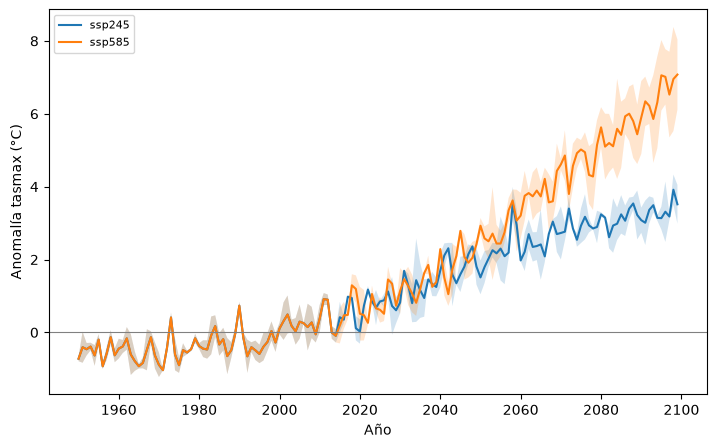

In [60]:
# Definir variable, mínimo y máximo
ensemble = series_anuales.mean("modelo")
e_min = series_anuales.min("modelo")
e_max = series_anuales.max("modelo")

fig, ax = plt.subplots(figsize=(8.5, 5))

for escenario in escenarios:
    ax.plot(ensemble["year"], ensemble.sel(escenario=escenario), label=f'{escenario}')
    ax.fill_between(ensemble["year"], e_min.sel(escenario=escenario), e_max.sel(escenario=escenario),
                     alpha=0.2)

ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Año")
ax.set_ylabel("Anomalía tasmax (°C)")
ax.legend(fontsize=8)
plt.show()

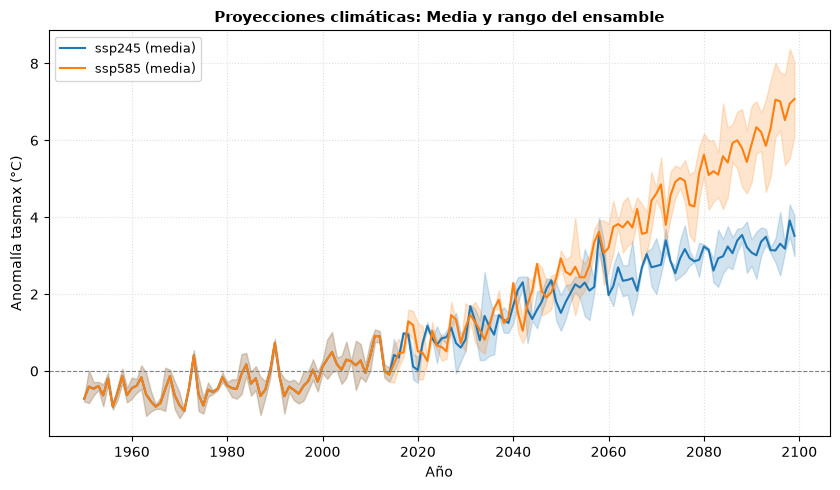

In [61]:
# Código chagepete
# 1. Reducciones sobre la dimensión 'modelo' sin sobreescribir funciones nativas
ensemble = series_anuales.mean("modelo")
ens_min  = series_anuales.min("modelo")
ens_max  = series_anuales.max("modelo")

# 2. Configuración de figura
fig, ax = plt.subplots(figsize=(8.5, 5))

# 3. Gráfica iterativa por escenario
for escenario in escenarios:
    years = ensemble["year"].values
    media = ensemble.sel(escenario=escenario).values
    ymin  = ens_min.sel(escenario=escenario).values
    ymax  = ens_max.sel(escenario=escenario).values
    
    # Graficar la media y capturar el objeto línea para sincronizar el color
    line = ax.plot(years, media, label=f'{escenario} (media)', lw=1.5)
    color = line[0].get_color()
    
    # Sombreado con el mismo color y sin duplicar texto redundante en la leyenda
    ax.fill_between(years, ymin, ymax, color=color, alpha=0.2)

# 4. Formato y ejes
ax.axhline(0, color="grey", lw=0.8, linestyle="--")
ax.set_xlabel("Año")
ax.set_ylabel("Anomalía tasmax (°C)")
ax.set_title("Proyecciones climáticas: Media y rango del ensamble", fontsize=11, weight="bold")
ax.legend(fontsize=9, frameon=True)
ax.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

### Ejercicio 4 

Grafica un mapa con cartopy comparando el cambio espacial de `tasmax` entre escenarios: por ejemplo, la anomalía media 2070-2099 de SSP2-4.5 junto a la de SSP5-8.5 (dos subplots), para uno de los dos modelos.

Pistas: usa `plt.subplots(1, 2, subplot_kw={"projection": ccrs.PlateCarree()})`, y el patrón de `ax.contourf(...)` + `ax.coastlines()`.

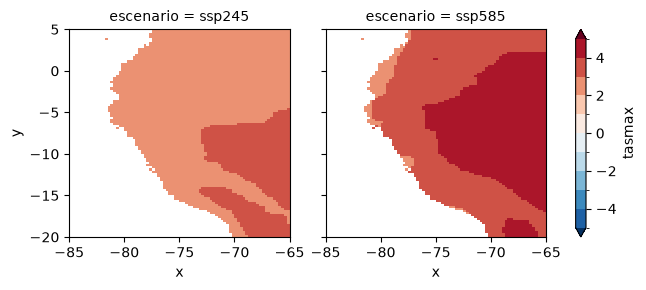

In [62]:
anom_prom = anomalia.mean("modelo")

anom_prom.sel(time=slice("2067-01-01", "2069-12-31")).mean("time").plot(
    cmap="RdBu_r", center=0, levels=np.arange(-5,6), extend='both', col="escenario",
)
plt.show()

In [63]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [64]:
import warnings
warnings.filterwarnings('ignore')

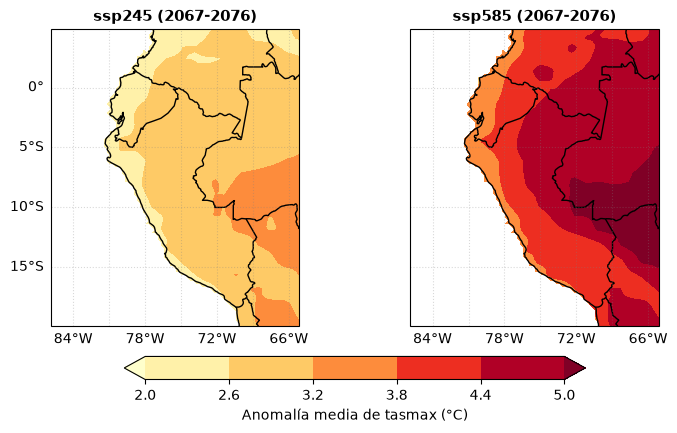

In [78]:
anom_67_76 = anom_prom.sel(time=slice("2067", "2076")).mean("time")

fig, axs = plt.subplots(1, 2, figsize=(8.5,5), subplot_kw={"projection": ccrs.PlateCarree()})
#plt.subplots_adjust(bottom=0.22, top=0.90, wspace=0.20)

escenarios = anom_67_76["escenario"].values
vmin = int(anom_67_76.min())
vmax = int(anom_67_76.max())

for ax, escenario in zip(axs, escenarios):
    mapa = anom_67_76.sel(escenario=escenario)

    cf = ax.contourf(mapa["x"].values, mapa["y"].values, mapa.values,
                     cmap="YlOrRd", transform=ccrs.PlateCarree(), levels=np.linspace(vmin,vmax,6), extend="both")
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    gl = ax.gridlines(draw_labels=False, color='gray', alpha=0.3, linestyle=":")
    gl.top_labels=False
    gl.right_labels=False
    gl.bottom_labels=True
    gl.left_labels= (ax == axs[0])

    ax.set_title(escenario+" (2067-2076)", fontsize=11, weight="bold")

#cbar_ax = fig.add_axes([0.25, 0.08, 0.50, 0.035])
cbar = fig.colorbar(cf, ax = axs, orientation="horizontal", shrink=0.7, pad=0.08, label="Anomalía media de tasmax (°C)")
plt.show()

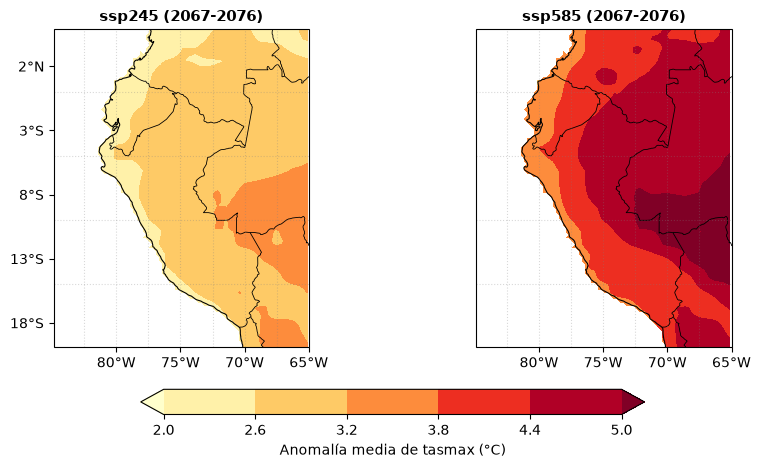

In [73]:
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

anom_67_76 = anom_prom.sel(time=slice("2067", "2076")).mean("time")

fig, axs = plt.subplots(1, 2, figsize=(10, 5.5), subplot_kw={"projection": ccrs.PlateCarree()})

escenarios = anom_67_76["escenario"].values
vmin = int(anom_67_76.min())
vmax = int(anom_67_76.max())

# Coordenadas mínimas y máximas de tu zona (Perú)
lon_min, lon_max = float(anom_67_76["x"].min()), float(anom_67_76["x"].max())
lat_min, lat_max = float(anom_67_76["y"].min()), float(anom_67_76["y"].max())

cf = None
for ax, escenario in zip(axs, escenarios):
    mapa = anom_67_76.sel(escenario=escenario)
    
    # Fijar el encuadre geográfico
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    cf = ax.contourf(
        mapa["x"].values, mapa["y"].values, mapa.values,
        cmap="YlOrRd", 
        transform=ccrs.PlateCarree(), 
        levels=np.linspace(vmin, vmax, 6), 
        extend="both"
    )
    
    ax.coastlines(resolution="50m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6)
    
    # Líneas de la grilla SIN draw_labels (para evitar el bug que colapsa la altura)
    ax.gridlines(draw_labels=False, color='gray', alpha=0.3, linestyle=":")
    
    # Ticks y etiquetas manuales (100% compatibles, nunca se rompen)
    ax.set_xticks(np.arange(-80, -64, 5), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    
    if ax == axs[0]:
        ax.set_yticks(np.arange(-18, 5, 5), crs=ccrs.PlateCarree())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
    
    ax.set_title(f"{escenario} (2067-2076)", fontsize=11, weight="bold")

# Colorbar horizontal integrado de forma estándar
cbar = fig.colorbar(
    cf, 
    ax=axs, 
    orientation="horizontal", 
    shrink=0.65, 
    pad=0.10, 
    label="Anomalía media de tasmax (°C)"
)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# 1. Promedio temporal 2070-2099
anom_futura = anom_prom.sel(time=slice("2070", "2099")).mean(dim="time")

vmax = float(np.nanmax(np.abs(anom_futura)))
niveles = np.linspace(0, vmax, 10)

# 2. Definir límites geográficos explícitos a partir de tus coordenadas

fig, axs = plt.subplots(
    1, 2, 
    figsize=(12, 6), 
    subplot_kw={"projection": ccrs.PlateCarree()}
)

escenarios = ["ssp245", "ssp585"]
titulos = ["SSP2-4.5 (2070-2099)", "SSP5-8.5 (2070-2099)"]

cf = None
for ax, esc, tit in zip(axs, escenarios, titulos):
    mapa = anom_futura.sel(escenario=esc)
    
    # Pintar datos
    cf = ax.contourf(
        mapa["x"].values, mapa["y"].values, mapa.values,
        levels=niveles,
        cmap="YlOrRd",
        transform=ccrs.PlateCarree(),
        extend="max"
    )
    
    # Costa y fronteras
    ax.coastlines(resolution="50m", linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
    
    # Cuadrícula SIN etiquetas de texto para evitar el bug de colapso
    ax.gridlines(draw_labels=False, color="gray", alpha=0.3, linestyle=":")
    
    ax.set_title(tit, fontsize=11, weight="bold")

# 3. Colorbar estándar
cbar = fig.colorbar(cf, ax=axs, orientation="horizontal", shrink=0.6, pad=0.08)
cbar.set_label("Anomalía media de tasmax (°C)", fontsize=10)

plt.show()